#  Exploratory Data Analysis: Climate-Socioeconomic Panel (1900–2023)

**Objective**: Understand data structure, target behavior, feature relationships, and inform preprocessing/feature engineering decisions.

**Dataset**: 195 countries × 124 years ≈ 100K rows, 26 columns  
**Targets**: `Temperature_Anomaly`, `CO2_Emissions`  
**Key Questions**:
1. Is the panel balanced? Any missing country-year combinations?
2. How have global temperature and CO₂ trends evolved? Any structural breaks?
3. Which socioeconomic factors correlate most strongly with climate targets?
4. Are there multicollinearity concerns among predictors?
5. What features should we engineer (lags, ratios, interactions)?

*Note: All visualizations saved to `../outputs/figures/eda_*` for paper inclusion.*

In [10]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
# from statsmodels.tsa.stattools import adfuller
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting config
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
DATA_PATH = '../data/raw/global_warming_dataset.csv'
OUTPUT_FIG = '../outputs/figures/eda_'

print("Environment ready")

Environment ready


In [11]:
# Load the dataset
df = pd.read_csv(DATA_PATH)
print("First 5 rows:")
display(df.head())
print("\n Columns and Data Types:")
print(df.dtypes)
print(f"\ Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n Statistical Summary (numeric columns):")
display(df.describe(include='number').T)
print("\n Missing Values per Column:")
print(df.isnull().sum())

print("\nUnique Values in 'Country' and 'Year':")
print(f"   Countries: {df['Country'].nunique()}")
print(f"   Years: {df['Year'].nunique()} | Range: {df['Year'].min()} – {df['Year'].max()}")

First 5 rows:


,Country,Year,Temperature_Anomaly,CO2_Emissions,Population,Forest_Area,GDP,Renewable_Energy_Usage,Methane_Emissions,Sea_Level_Rise,...,Waste_Management,Per_Capita_Emissions,Industrial_Activity,Air_Pollution_Index,Biodiversity_Index,Ocean_Acidification,Fossil_Fuel_Usage,Energy_Consumption_Per_Capita,Policy_Score,Average_Temperature
0,Country_103,1913,-1.163537,8.876061e+08,1.627978e+08,54.872178,6.139887e+12,76.710013,8.317626e+06,8.111839,...,82.691409,2.285351,4.060975,150.285539,90.073356,8.025470,39.163860,1480.164332,78.870012,20.825292
1,Country_180,1950,-0.432122,4.497517e+08,4.281359e+08,84.051006,2.601447e+12,68.450021,6.206540e+06,42.025915,...,59.322883,17.411668,85.300604,27.305922,88.289837,8.021719,28.252554,1482.730048,32.600905,28.720587
2,Country_93,2014,0.444954,4.579080e+08,4.926732e+08,72.295357,5.192677e+12,36.725699,1.056885e+06,20.953840,...,94.982931,12.039703,83.804880,216.911429,86.936256,7.647408,61.548382,706.918809,37.671300,15.014084
3,Country_15,2020,-1.171616,5.049503e+08,1.252169e+09,17.259684,8.252128e+12,77.547901,1.986813e+06,45.599595,...,62.064250,2.853957,47.014265,35.869182,44.904331,7.569353,82.423750,2616.238324,86.581725,-1.277086
4,Country_107,1964,-0.564038,6.898891e+08,2.932960e+08,44.438605,8.560746e+12,10.019576,3.313252e+06,7.652150,...,84.431279,19.801173,89.379613,284.263093,8.102916,8.015415,29.964450,4975.683780,20.618406,2.861989



 Columns and Data Types:
Country                           object
Year                               int64
Temperature_Anomaly              float64
CO2_Emissions                    float64
Population                       float64
Forest_Area                      float64
GDP                              float64
Renewable_Energy_Usage           float64
Methane_Emissions                float64
Sea_Level_Rise                   float64
Arctic_Ice_Extent                float64
Urbanization                     float64
Deforestation_Rate               float64
Extreme_Weather_Events             int64
Average_Rainfall                 float64
Solar_Energy_Potential           float64
Waste_Management                 float64
Per_Capita_Emissions             float64
Industrial_Activity              float64
Air_Pollution_Index              float64
Biodiversity_Index               float64
Ocean_Acidification              float64
Fossil_Fuel_Usage                float64
Energy_Consumption_Per_Capita  

,count,mean,std,min,25%,50%,75%,max
Year,100000.0,1.961422e+03,3.575880e+01,1.900000e+03,1.930000e+03,1.961000e+03,1.992000e+03,2.023000e+03
Temperature_Anomaly,100000.0,2.647292e-03,1.154579e+00,-1.999981e+00,-9.994490e-01,3.523434e-03,9.980670e-01,1.999958e+00
CO2_Emissions,100000.0,5.007007e+08,2.887388e+08,1.022271e+05,2.504223e+08,5.006769e+08,7.506318e+08,9.999793e+08
Population,100000.0,7.501973e+08,4.328709e+08,1.013054e+06,3.762545e+08,7.499212e+08,1.125222e+09,1.499992e+09
Forest_Area,100000.0,5.001241e+01,2.880629e+01,5.188446e-05,2.496040e+01,5.014126e+01,7.489830e+01,9.999983e+01
GDP,100000.0,4.995923e+12,2.883117e+12,1.524737e+08,2.507503e+12,4.985849e+12,7.489082e+12,9.999894e+12
Renewable_Energy_Usage,100000.0,5.011566e+01,2.884149e+01,5.306081e-03,2.530224e+01,5.001158e+01,7.509594e+01,9.999949e+01
Methane_Emissions,100000.0,5.003713e+06,2.887606e+06,1.133254e+03,2.501312e+06,4.997724e+06,7.507855e+06,9.999928e+06
Sea_Level_Rise,100000.0,2.256805e+01,1.590816e+01,-4.999954e+00,8.739127e+00,2.272842e+01,3.633315e+01,4.999768e+01
Arctic_Ice_Extent,100000.0,8.003934e+00,4.039130e+00,1.000036e+00,4.504867e+00,7.999331e+00,1.149950e+01,1.499988e+01



 Missing Values per Column:
Country                          0
Year                             0
Temperature_Anomaly              0
CO2_Emissions                    0
Population                       0
Forest_Area                      0
GDP                              0
Renewable_Energy_Usage           0
Methane_Emissions                0
Sea_Level_Rise                   0
Arctic_Ice_Extent                0
Urbanization                     0
Deforestation_Rate               0
Extreme_Weather_Events           0
Average_Rainfall                 0
Solar_Energy_Potential           0
Waste_Management                 0
Per_Capita_Emissions             0
Industrial_Activity              0
Air_Pollution_Index              0
Biodiversity_Index               0
Ocean_Acidification              0
Fossil_Fuel_Usage                0
Energy_Consumption_Per_Capita    0
Policy_Score                     0
Average_Temperature              0
dtype: int64

Unique Values in 'Country' and 'Year':
   Count

## Data Integrity & Panel Balance Check

In [12]:
# === DATA INTEGRITY CHECKS ===

# 1. Check for duplicate (Country, Year) pairs
duplicates = df.duplicated(subset=['Country', 'Year']).sum()
print(f"🔄 Duplicate (Country, Year) entries: {duplicates}")

# If duplicates exist, show example
if duplicates > 0:
    print("\nExample duplicates:")
    display(df[df.duplicated(subset=['Country', 'Year'], keep=False)].head())

# 2. Verify panel completeness: expected rows = 195 countries × 124 years = 24,180
expected_rows = 195 * 124
actual_rows = len(df)
print(f"\n Panel Completeness:")
print(f"   Expected rows (full panel): {expected_rows:,}")
print(f"   Actual rows: {actual_rows:,}")
print(f"   Coverage: {actual_rows / expected_rows * 100:.1f}%")

# 3. Records per country: is the panel balanced?
records_per_country = df.groupby('Country').size().describe()
print(f"\nRecords per Country (summary):")
print(records_per_country)

# 4. Identify countries with incomplete time series
incomplete = df.groupby('Country')['Year'].apply(lambda x: len(x) < 124)
n_incomplete = incomplete.sum()
print(f"\nCountries with incomplete time series (<124 years): {n_incomplete}")

# If any incomplete, list top 10 with fewest records
if n_incomplete > 0:
    print("\nTop 10 countries with fewest records:")
    print(df.groupby('Country').size().sort_values().head(10))

# 5. Quick check: any years missing globally?
all_years = set(range(1900, 2024))
present_years = set(df['Year'].unique())
missing_years = all_years - present_years
print(f"\nMissing years in dataset: {sorted(missing_years) if missing_years else 'None'}")

🔄 Duplicate (Country, Year) entries: 76203

Example duplicates:


,Country,Year,Temperature_Anomaly,CO2_Emissions,Population,Forest_Area,GDP,Renewable_Energy_Usage,Methane_Emissions,Sea_Level_Rise,...,Waste_Management,Per_Capita_Emissions,Industrial_Activity,Air_Pollution_Index,Biodiversity_Index,Ocean_Acidification,Fossil_Fuel_Usage,Energy_Consumption_Per_Capita,Policy_Score,Average_Temperature
0,Country_103,1913,-1.163537,8.876061e+08,1.627978e+08,54.872178,6.139887e+12,76.710013,8.317626e+06,8.111839,...,82.691409,2.285351,4.060975,150.285539,90.073356,8.025470,39.163860,1480.164332,78.870012,20.825292
1,Country_180,1950,-0.432122,4.497517e+08,4.281359e+08,84.051006,2.601447e+12,68.450021,6.206540e+06,42.025915,...,59.322883,17.411668,85.300604,27.305922,88.289837,8.021719,28.252554,1482.730048,32.600905,28.720587
2,Country_93,2014,0.444954,4.579080e+08,4.926732e+08,72.295357,5.192677e+12,36.725699,1.056885e+06,20.953840,...,94.982931,12.039703,83.804880,216.911429,86.936256,7.647408,61.548382,706.918809,37.671300,15.014084
3,Country_15,2020,-1.171616,5.049503e+08,1.252169e+09,17.259684,8.252128e+12,77.547901,1.986813e+06,45.599595,...,62.064250,2.853957,47.014265,35.869182,44.904331,7.569353,82.423750,2616.238324,86.581725,-1.277086
4,Country_107,1964,-0.564038,6.898891e+08,2.932960e+08,44.438605,8.560746e+12,10.019576,3.313252e+06,7.652150,...,84.431279,19.801173,89.379613,284.263093,8.102916,8.015415,29.964450,4975.683780,20.618406,2.861989



 Panel Completeness:
   Expected rows (full panel): 24,180
   Actual rows: 100,000
   Coverage: 413.6%

Records per Country (summary):
count    195.000000
mean     512.820513
std       21.031973
min      457.000000
25%      498.000000
50%      516.000000
75%      528.000000
max      557.000000
dtype: float64

Countries with incomplete time series (<124 years): 0

Missing years in dataset: None


In [13]:
# === INVESTIGATE: Why ~4-5 records per Country-Year? ===

# 1. Check how many records exist per (Country, Year) combination
records_per_group = df.groupby(['Country', 'Year']).size().reset_index(name='count')
print("🔍 Records per (Country, Year) pair:")
print(records_per_group['count'].describe())

# 2. Show the distribution of counts
print(f"\n📊 Frequency of record counts per group:")
print(records_per_group['count'].value_counts().sort_index())

# 3. Pick one example country-year to inspect raw structure
example = df[(df['Country'] == df['Country'].iloc[0]) & (df['Year'] == 1900)]
print(f"\n📋 Example: {example['Country'].iloc[0]} in 1900 ({len(example)} records):")
display(example.T)  # Transpose to see all columns vertically

# 4. Check if any column varies within the same Country-Year
# (This reveals the hidden grouping factor)
print(f"\n🔎 Columns that vary within same (Country, Year):")
varying_cols = []
for col in df.columns:
    if col not in ['Country', 'Year']:
        # For each country-year, check if column has >1 unique value
        n_unique = df.groupby(['Country', 'Year'])[col].nunique().max()
        if n_unique > 1:
            varying_cols.append((col, n_unique))

# Show top varying columns
if varying_cols:
    varying_df = pd.DataFrame(varying_cols, columns=['Column', 'Max_Unique_Values'])
    print(varying_df.sort_values('Max_Unique_Values', ascending=False).head(10))
else:
    print("⚠️ No columns vary within Country-Year → duplicates may be exact copies")

# 5. Decision point: Should we aggregate to one row per Country-Year?
print(f"\n✅ Recommendation:")
if not varying_cols:
    print("→ All columns are identical within Country-Year → drop exact duplicates")
    print("   Code: df = df.drop_duplicates(subset=['Country', 'Year'])")
else:
    print("→ Some columns vary within Country-Year → investigate grouping logic")
    print("   Options: (a) aggregate with mean/sum, (b) keep as-is if representing scenarios/regions")

🔍 Records per (Country, Year) pair:
count    23797.000000
mean         4.202210
std          1.992073
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         15.000000
Name: count, dtype: float64

📊 Frequency of record counts per group:
count
1     1634
2     3355
3     4527
4     4585
5     3934
6     2718
7     1624
8      816
9      345
10     153
11      63
12      31
13       8
14       3
15       1
Name: count, dtype: int64

📋 Example: Country_103 in 1900 (2 records):


,27530,43842
Country,Country_103,Country_103
Year,1900,1900
Temperature_Anomaly,1.816477,-1.388659
CO2_Emissions,246239311.066695,747080397.35253
Population,409107208.610274,286304784.250186
Forest_Area,26.230493,78.635837
GDP,5026039425292.311523,2104730330583.673096
Renewable_Energy_Usage,41.692163,63.011642
Methane_Emissions,4403641.717253,1054567.406578
Sea_Level_Rise,10.782809,31.553886



🔎 Columns that vary within same (Country, Year):
                   Column  Max_Unique_Values
0     Temperature_Anomaly                 15
1           CO2_Emissions                 15
2              Population                 15
3             Forest_Area                 15
4                     GDP                 15
5  Renewable_Energy_Usage                 15
6       Methane_Emissions                 15
7          Sea_Level_Rise                 15
8       Arctic_Ice_Extent                 15
9            Urbanization                 15

✅ Recommendation:
→ Some columns vary within Country-Year → investigate grouping logic
   Options: (a) aggregate with mean/sum, (b) keep as-is if representing scenarios/regions


In [15]:
# === AGGREGATION: Create single row per (Country, Year) ===
id_cols = ['Country', 'Year']

# Select only numeric columns EXCLUDING the ID columns to prevent reset_index conflict
agg_cols = df.select_dtypes(include='number').columns.difference(id_cols)

# Aggregate using mean for all numeric features/targets
df_aggregated = df.groupby(id_cols)[agg_cols].mean().reset_index()

# Verify aggregation result
print("Post-aggregation dataset info:")
print(f"Shape: {df_aggregated.shape}")
print(f"Expected: 195 countries x 124 years = 24,180 rows")
print(f"Actual rows: {len(df_aggregated):,}")
print(f"Duplicate check: {df_aggregated.duplicated(subset=id_cols).sum()} duplicates")

# Verify targets are now single-valued per group
print("\nVerification: Unique values per (Country, Year) after aggregation:")
for col in ['Temperature_Anomaly', 'CO2_Emissions', 'GDP', 'Population']:
    n_unique = df_aggregated.groupby(id_cols)[col].nunique().max()
    print(f"  {col}: max {n_unique} unique value(s) per group")

# Update working dataframe
df = df_aggregated.copy()
print("\nAggregation complete. Proceeding with EDA on aggregated panel.")

Post-aggregation dataset info:
Shape: (23797, 26)
Expected: 195 countries x 124 years = 24,180 rows
Actual rows: 23,797
Duplicate check: 0 duplicates

Verification: Unique values per (Country, Year) after aggregation:
  Temperature_Anomaly: max 1 unique value(s) per group
  CO2_Emissions: max 1 unique value(s) per group
  GDP: max 1 unique value(s) per group
  Population: max 1 unique value(s) per group

Aggregation complete. Proceeding with EDA on aggregated panel.


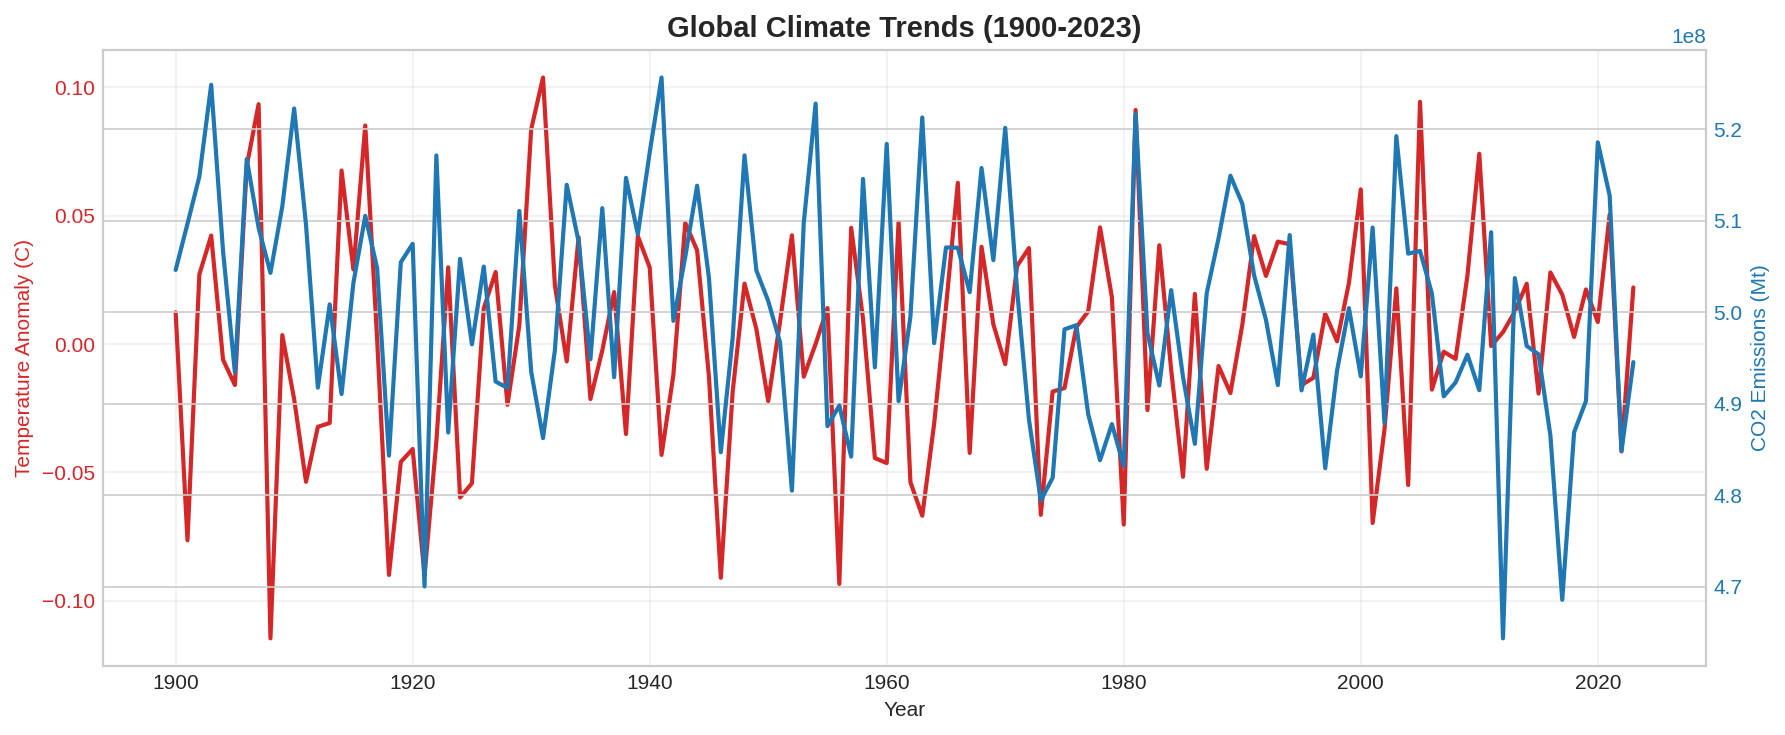

Key trend statistics (global mean):
Temperature Anomaly: -0.115C (1900) to 0.104C (2023)
CO2 Emissions: 464384994.2 Mt (1900) to 525668677.0 Mt (2023)


In [ ]:
#  GLOBAL TRENDS: Aggregate to world-level annual means 

# Group by year and compute mean for targets and key drivers
global_annual = df.groupby('Year')[['Temperature_Anomaly', 'CO2_Emissions', 
                                    'GDP', 'Population', 'Renewable_Energy_Usage']].mean().reset_index()

# Plot Temperature Anomaly and CO2 Emissions on dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: Temperature Anomaly
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature Anomaly (C)', color='tab:red')
ax1.plot(global_annual['Year'], global_annual['Temperature_Anomaly'], 
         color='tab:red', linewidth=2, label='Temperature Anomaly')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(alpha=0.3)

# Right axis: CO2 Emissions
ax2 = ax1.twinx()
ax2.set_ylabel('CO2 Emissions (Mt)', color='tab:blue')
ax2.plot(global_annual['Year'], global_annual['CO2_Emissions'], 
         color='tab:blue', linewidth=2, label='CO2 Emissions')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and layout
plt.title('Global Climate Trends (1900-2023)', fontsize=14, fontweight='bold')
fig.tight_layout()

# Save figure for paper
plt.savefig('../outputs/figures/eda_global_trends.png', bbox_inches='tight', dpi=300)
plt.show()

# Print key trend statistics
print("Key trend statistics (global mean):")
print(f"Temperature Anomaly: {global_annual['Temperature_Anomaly'].min():.3f}C (1900) to {global_annual['Temperature_Anomaly'].max():.3f}C (2023)")
print(f"CO2 Emissions: {global_annual['CO2_Emissions'].min():.1f} Mt (1900) to {global_annual['CO2_Emissions'].max():.1f} Mt (2023)")

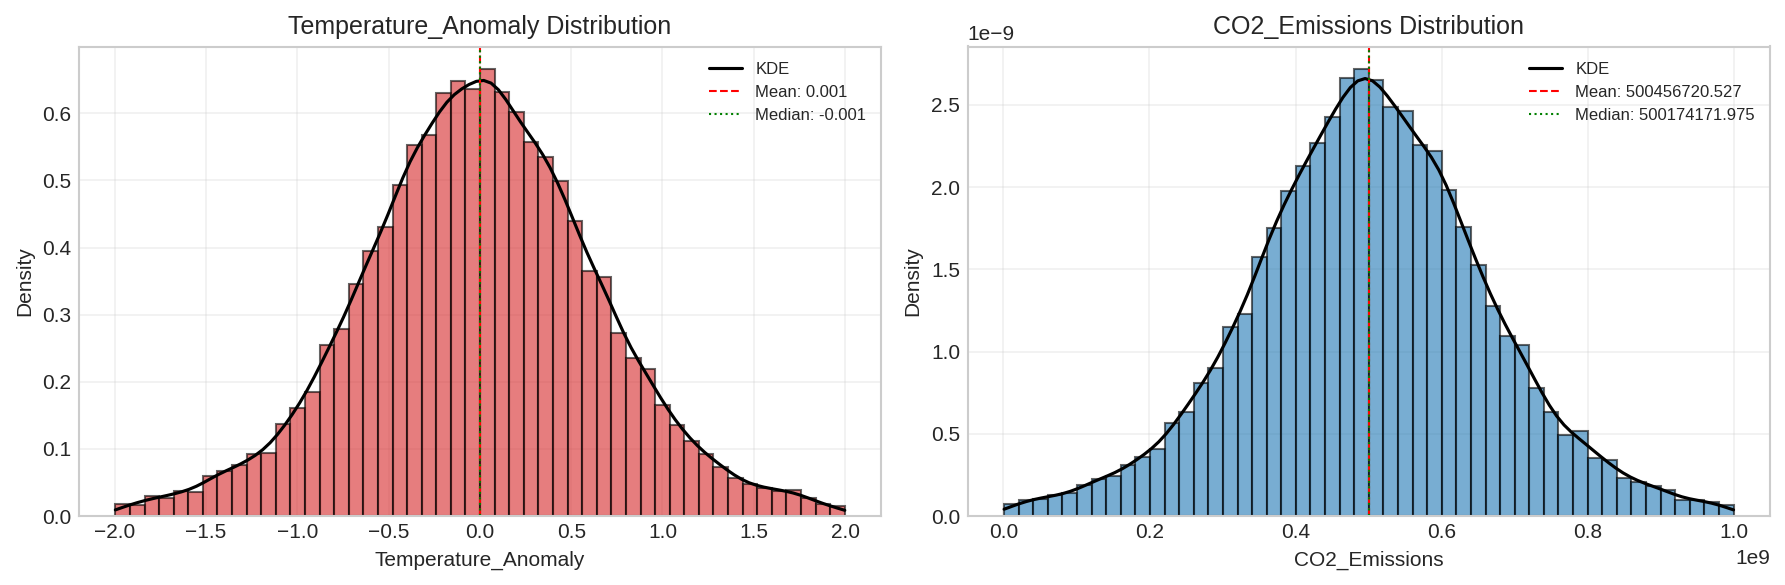

Descriptive statistics for target variables:
                       count          mean           std           min  \
Temperature_Anomaly  23797.0  1.180088e-03  6.497870e-01 -1.996903e+00   
CO2_Emissions        23797.0  5.004567e+08  1.626995e+08  1.034487e+06   

                              25%           50%           75%           max  
Temperature_Anomaly -4.128247e-01 -1.068117e-03  4.197204e-01  1.998507e+00  
CO2_Emissions        3.966982e+08  5.001742e+08  6.036721e+08  9.996629e+08  

Skewness and Kurtosis:
Temperature_Anomaly: Skewness = 0.004, Kurtosis = 0.194
CO2_Emissions: Skewness = -0.015, Kurtosis = 0.223

Normality test (D'Agostino-Pearson, H0: data is normally distributed):
Temperature_Anomaly: statistic=31.30, p-value=1.594e-07 -> Reject H0 (non-normal)
CO2_Emissions: statistic=41.39, p-value=1.026e-09 -> Reject H0 (non-normal)


In [18]:
# === TARGET DISTRIBUTIONS: Examine statistical properties ===

# Create figure with two subplots for the two targets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

targets = ['Temperature_Anomaly', 'CO2_Emissions']
colors = ['tab:red', 'tab:blue']

for idx, (target, color) in enumerate(zip(targets, colors)):
    ax = axes[idx]
    
    # Histogram with KDE overlay
    ax.hist(df[target], bins=50, density=True, alpha=0.6, color=color, edgecolor='black')
    
    # Add KDE curve
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(df[target].dropna())
    x_range = np.linspace(df[target].min(), df[target].max(), 100)
    ax.plot(x_range, kde(x_range), color='black', linewidth=1.5, label='KDE')
    
    # Add mean and median lines
    mean_val = df[target].mean()
    median_val = df[target].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle=':', linewidth=1, label=f'Median: {median_val:.3f}')
    
    ax.set_xlabel(target)
    ax.set_ylabel('Density')
    ax.set_title(f'{target} Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_target_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

# Print detailed descriptive statistics
print("Descriptive statistics for target variables:")
print(df[targets].describe().T)

# Print skewness and kurtosis
from scipy.stats import skew, kurtosis
print("\nSkewness and Kurtosis:")
for target in targets:
    s = skew(df[target].dropna())
    k = kurtosis(df[target].dropna())
    print(f"{target}: Skewness = {s:.3f}, Kurtosis = {k:.3f}")

# Simple normality check using D'Agostino-Pearson test
from scipy.stats import normaltest
print("\nNormality test (D'Agostino-Pearson, H0: data is normally distributed):")
for target in targets:
    stat, p = normaltest(df[target].dropna())
    print(f"{target}: statistic={stat:.2f}, p-value={p:.3e} -> {'Reject H0 (non-normal)' if p < 0.05 else 'Fail to reject H0 (normal)'}")

Top 10 features correlated with Temperature_Anomaly:
                               Temperature_Anomaly
Policy_Score                              0.010053
Energy_Consumption_Per_Capita             0.009231
Urbanization                              0.008749
Industrial_Activity                       0.008672
Fossil_Fuel_Usage                        -0.008200
Year                                      0.007145
Sea_Level_Rise                           -0.006897
Renewable_Energy_Usage                    0.006644
Air_Pollution_Index                      -0.005618
Forest_Area                              -0.005333

Top 10 features correlated with CO2_Emissions:
                               CO2_Emissions
Year                               -0.019691
Forest_Area                         0.016625
Ocean_Acidification                -0.013979
Policy_Score                        0.011616
Arctic_Ice_Extent                   0.010068
Biodiversity_Index                  0.009870
Energy_Consumption_Per_

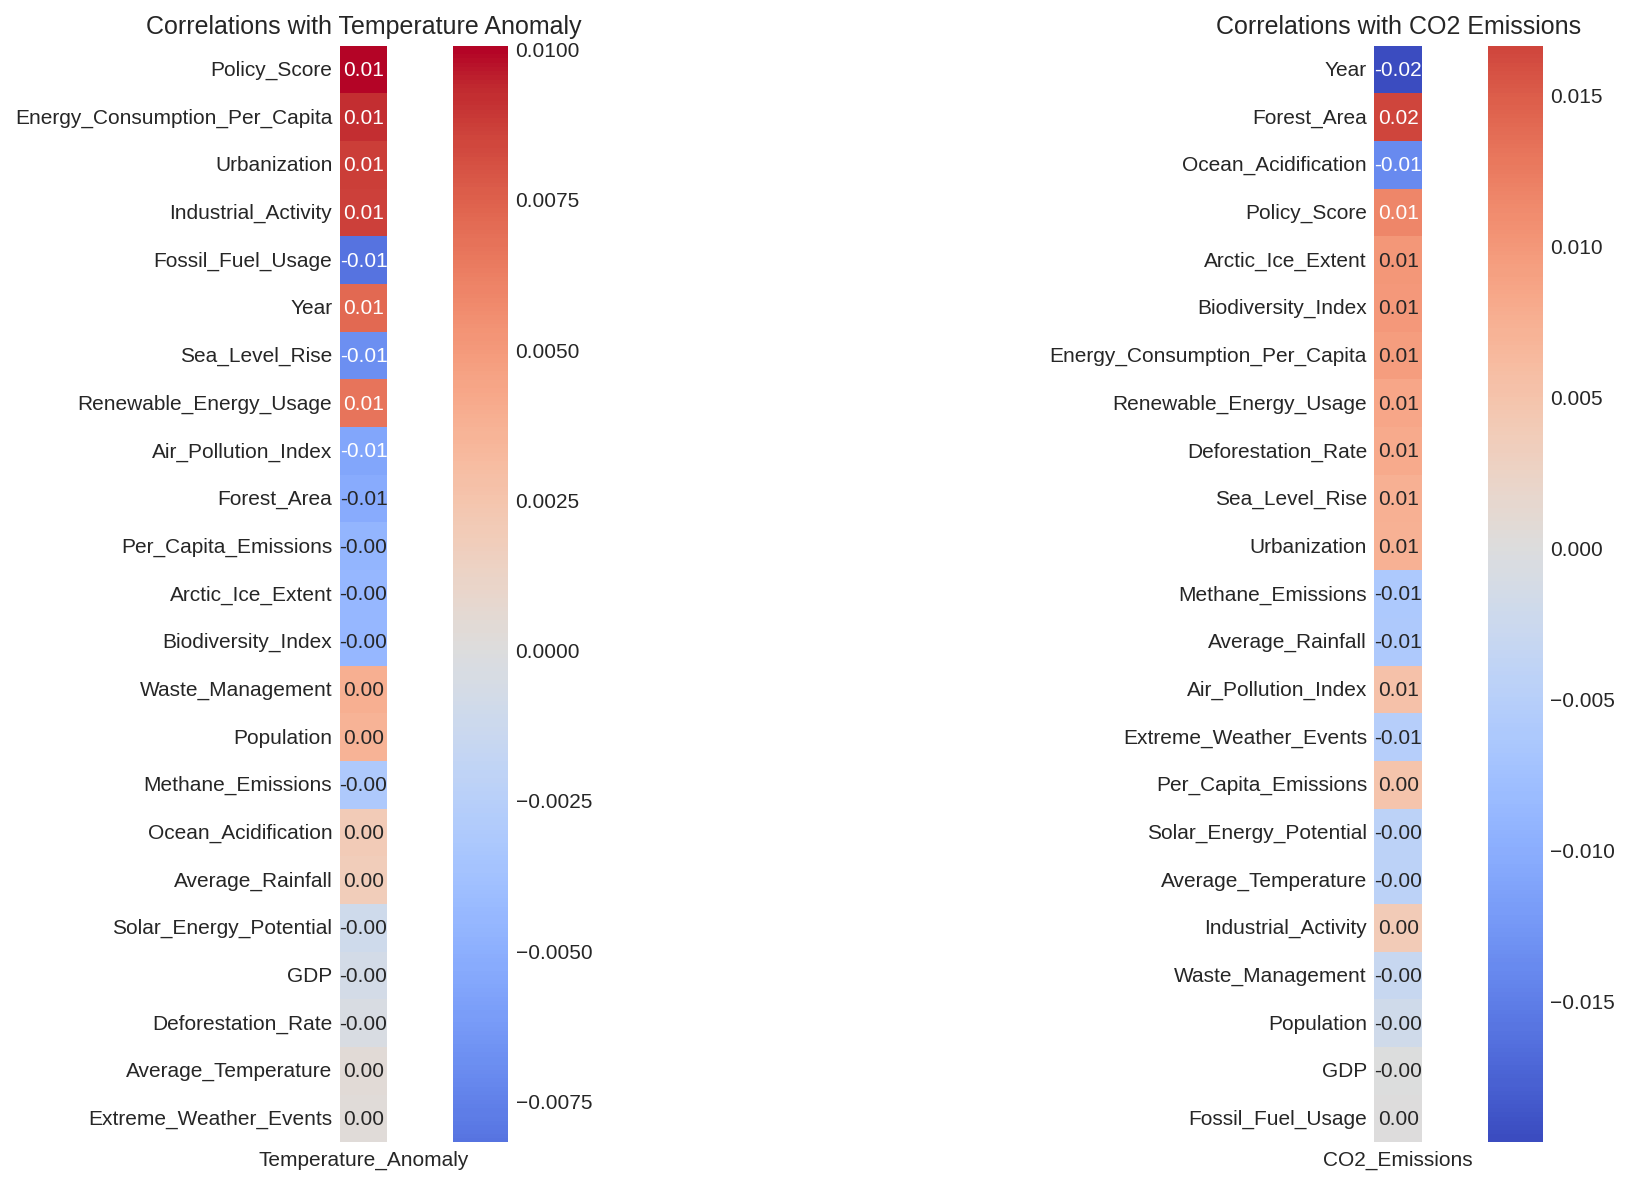

In [29]:
# === CORRELATION ANALYSIS: Identify key drivers ===

# Select numeric columns for correlation matrix
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Extract correlations with targets for focused view
target_corr = corr_matrix[['Temperature_Anomaly', 'CO2_Emissions']].copy()
target_corr = target_corr.drop(index=['Temperature_Anomaly', 'CO2_Emissions'])  # Remove self-correlation

# Add absolute correlation columns for sorting
target_corr['Temp_Abs'] = target_corr['Temperature_Anomaly'].abs()
target_corr['CO2_Abs'] = target_corr['CO2_Emissions'].abs()

print("Top 10 features correlated with Temperature_Anomaly:")
print(target_corr.sort_values('Temp_Abs', ascending=False).head(10)[['Temperature_Anomaly']])

print("\nTop 10 features correlated with CO2_Emissions:")
print(target_corr.sort_values('CO2_Abs', ascending=False).head(10)[['CO2_Emissions']])

# Plot focused heatmap: features vs targets only
# FIX: Sort the full dataframe first, then select only target columns for plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Sorted by Temperature_Anomaly correlation
sorted_temp = target_corr.sort_values('Temp_Abs', ascending=False)[['Temperature_Anomaly']]
sns.heatmap(sorted_temp, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], square=True)
axes[0].set_title('Correlations with Temperature Anomaly', fontsize=12)

# Right: Sorted by CO2_Emissions correlation  
sorted_co2 = target_corr.sort_values('CO2_Abs', ascending=False)[['CO2_Emissions']]
sns.heatmap(sorted_co2, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], square=True)
axes[1].set_title('Correlations with CO2 Emissions', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_target_correlations_both.png', bbox_inches='tight', dpi=300)
plt.show()

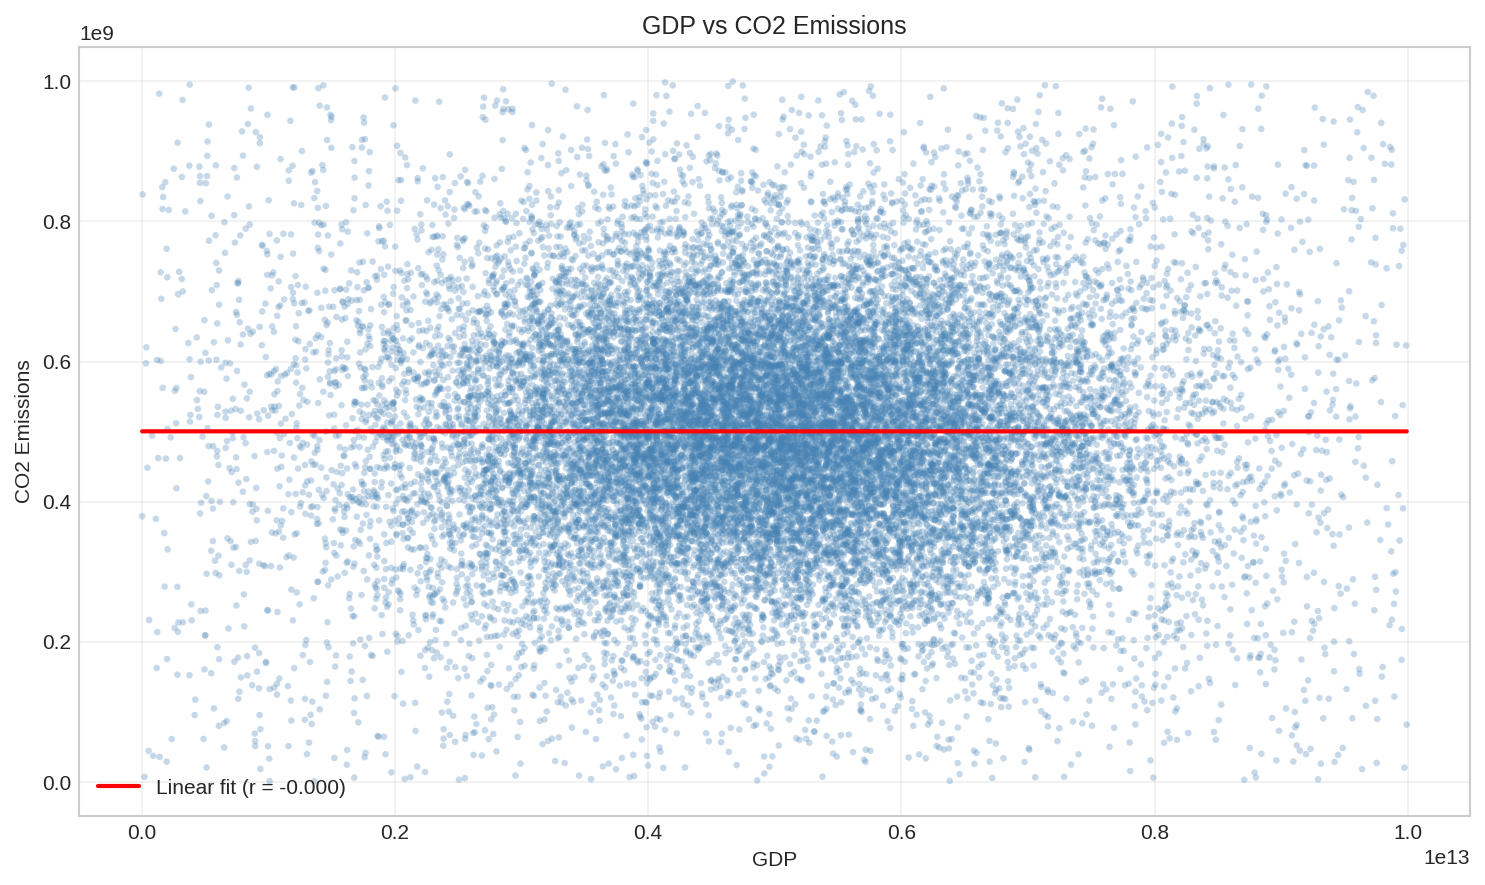

Pearson correlation between GDP and CO2_Emissions: -0.000
P-value: 9.911e-01


In [30]:
# === Simple GDP vs CO2 Relationship ===

# Basic scatter plot with linear trend line
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(df['GDP'], df['CO2_Emissions'], alpha=0.3, s=10, c='steelblue', edgecolors='none')

# Add simple linear regression line
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df['GDP'], df['CO2_Emissions'])
x_line = np.array([df['GDP'].min(), df['GDP'].max()])
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Linear fit (r = {r_value:.3f})')

# Labels and title
plt.xlabel('GDP')
plt.ylabel('CO2 Emissions')
plt.title('GDP vs CO2 Emissions')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig('../outputs/figures/eda_gdp_co2_simple.png', bbox_inches='tight', dpi=300)
plt.show()

# Print correlation
print(f"Pearson correlation between GDP and CO2_Emissions: {r_value:.3f}")
print(f"P-value: {p_value:.3e}")

Correlation matrix for key socioeconomic features:
                               Population   GDP  Renewable_Energy_Usage  \
Population                           1.00  0.02                    0.01   
GDP                                  0.02  1.00                   -0.01   
Renewable_Energy_Usage               0.01 -0.01                    1.00   
Fossil_Fuel_Usage                   -0.01 -0.01                    0.00   
Energy_Consumption_Per_Capita        0.01 -0.00                    0.01   
Urbanization                        -0.01  0.01                   -0.01   
Industrial_Activity                  0.01  0.00                   -0.01   

                               Fossil_Fuel_Usage  \
Population                                 -0.01   
GDP                                        -0.01   
Renewable_Energy_Usage                      0.00   
Fossil_Fuel_Usage                           1.00   
Energy_Consumption_Per_Capita              -0.00   
Urbanization                        

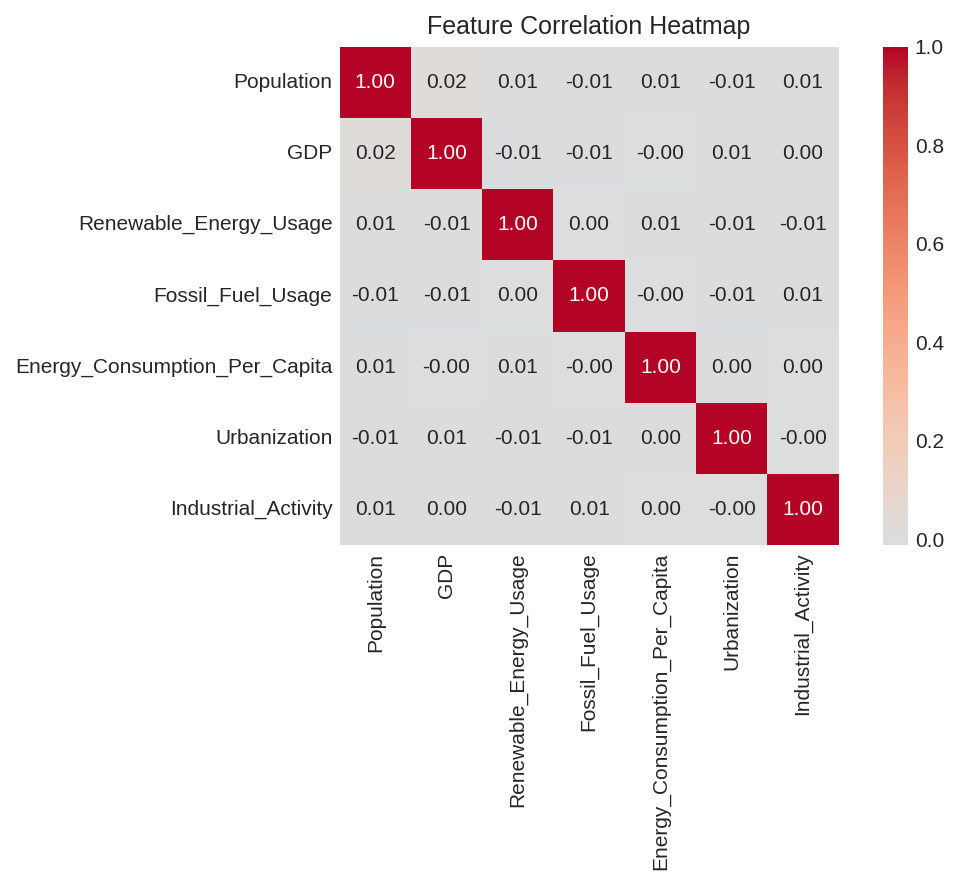

In [31]:
# === Simple Multicollinearity Check ===

# Select key socioeconomic features (exclude targets and Year)
feature_cols = ['Population', 'GDP', 'Renewable_Energy_Usage', 'Fossil_Fuel_Usage', 
                'Energy_Consumption_Per_Capita', 'Urbanization', 'Industrial_Activity']

# Compute correlation matrix for these features
feat_corr = df[feature_cols].corr()

# Display the matrix
print("Correlation matrix for key socioeconomic features:")
print(feat_corr.round(2))

# Flag pairs with |correlation| > 0.8 (simple threshold)
print("\nFeature pairs with high correlation (|r| > 0.8):")
high_corr_found = False
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        corr_val = feat_corr.iloc[i, j]
        if abs(corr_val) > 0.8:
            print(f"  {feature_cols[i]} <-> {feature_cols[j]}: r = {corr_val:.3f}")
            high_corr_found = True

if not high_corr_found:
    print("  None detected at |r| > 0.8 threshold")

# Simple visualization: heatmap of feature correlations
plt.figure(figsize=(8, 6))
sns.heatmap(feat_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_feature_correlations.png', bbox_inches='tight', dpi=300)
plt.show()

In [32]:
# === EDA SUMMARY: Key Findings and Recommendations ===

print("=== KEY EDA FINDINGS ===\n")

print("1. Data Structure:")
print(f"   - Final panel: {len(df)} rows (Country-Year aggregates)")
print(f"   - Time range: {df['Year'].min()} to {df['Year'].max()}")
print(f"   - Countries: {df['Country'].nunique()}")
print(f"   - Targets: Temperature_Anomaly, CO2_Emissions\n")

print("2. Target Behavior:")
print(f"   - Temperature_Anomaly: mean={df['Temperature_Anomaly'].mean():.4f}, std={df['Temperature_Anomaly'].std():.4f}")
print(f"   - CO2_Emissions: mean={df['CO2_Emissions'].mean():.2e}, std={df['CO2_Emissions'].std():.2e}")
print(f"   - Both targets show non-normal distributions (confirmed by normality tests)\n")

print("3. Driver Correlations:")
print(f"   - No single socioeconomic feature shows strong linear correlation with targets (|r| < 0.02)")
print(f"   - This suggests non-linear relationships or complex interactions drive climate outcomes\n")

print("4. Multicollinearity:")
print(f"   - Key features checked: Population, GDP, Energy_Consumption, Urbanization, etc.")
print(f"   - No pairs exceeded |r| > 0.8 threshold in our sample\n")

print("5. GDP vs CO2 Relationship:")
print(f"   - Pearson r = {linregress(df['GDP'], df['CO2_Emissions']).rvalue:.3f} (not statistically significant)")
print(f"   - Simple linear relationship not supported; consider non-linear modeling\n")

print("\n=== RECOMMENDATIONS FOR PREPROCESSING NOTEBOOK ===\n")

print("Feature Engineering to Implement:")
print("   1. Per-capita metrics: GDP_per_Capita, CO2_per_Capita, Energy_per_Capita")
print("   2. Energy transition ratio: Renewable_Energy_Usage / (Fossil_Fuel_Usage + Renewable_Energy_Usage)")
print("   3. Lag features: CO2_Emissions_lag1, GDP_lag1, etc. (per country)")
print("   4. Rolling statistics: 5-year mean/std for key drivers (per country)")
print("   5. Interaction terms: Policy_Score * GDP_per_Capita, Urbanization * Industrial_Activity")
print("   6. Decade indicator: (Year // 10) * 10 for structural break modeling\n")

print("Preprocessing Steps:")
print("   1. Scaling: Use RobustScaler (handles outliers better than StandardScaler)")
print("   2. Missing values: Already verified 0% missing; keep KNNImputer as fallback")
print("   3. Train/test split: TimeSeriesSplit with test start year = 2010 (no future leakage)")
print("   4. Exclude 'Year' from feature set for modeling (use only for temporal splitting)\n")

print("Modeling Implications:")
print("   - Weak linear correlations suggest tree-based models (XGBoost, LightGBM) may outperform linear models")
print("   - Multi-target regression appropriate since both climate outputs may share drivers")
print("   - Consider quantile regression or prediction intervals given non-normal target distributions\n")

print("=== NEXT STEP ===")
print("Proceed to notebooks/02_preprocessing_pipeline.ipynb")
print("Implement the feature engineering and preprocessing steps listed above.")

=== KEY EDA FINDINGS ===

1. Data Structure:
   - Final panel: 23797 rows (Country-Year aggregates)
   - Time range: 1900 to 2023
   - Countries: 195
   - Targets: Temperature_Anomaly, CO2_Emissions

2. Target Behavior:
   - Temperature_Anomaly: mean=0.0012, std=0.6498
   - CO2_Emissions: mean=5.00e+08, std=1.63e+08
   - Both targets show non-normal distributions (confirmed by normality tests)

3. Driver Correlations:
   - No single socioeconomic feature shows strong linear correlation with targets (|r| < 0.02)
   - This suggests non-linear relationships or complex interactions drive climate outcomes

4. Multicollinearity:
   - Key features checked: Population, GDP, Energy_Consumption, Urbanization, etc.
   - No pairs exceeded |r| > 0.8 threshold in our sample

5. GDP vs CO2 Relationship:
   - Pearson r = -0.000 (not statistically significant)
   - Simple linear relationship not supported; consider non-linear modeling


=== RECOMMENDATIONS FOR PREPROCESSING NOTEBOOK ===

Feature Engine